In [1]:
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly
plotly.offline.init_notebook_mode(connected=True)

from numpy.random import default_rng

from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import mean_squared_error

import umap

from sklearn import datasets, manifold
from scipy.optimize import minimize


import GPy

import warnings
warnings.filterwarnings('ignore')

2025-07-16 14:09:15.886446: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752700155.899949 1539902 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752700155.904080 1539902 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752700155.915859 1539902 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752700155.915871 1539902 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752700155.915872 1539902 computation_placer.cc:177] computation placer alr

In [2]:
def my_2DS():
    n_samples = 1500
    S_points, S_color = datasets.make_s_curve(n_samples, random_state=0)
    return S_points

Y = my_2DS()


fig = go.Figure(data=[go.Scatter3d(
    x=Y[:,0],y=Y[:,1],z=Y[:,2], mode='markers', marker=dict( size=5, color=Y[:, 2], colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

# UMAP

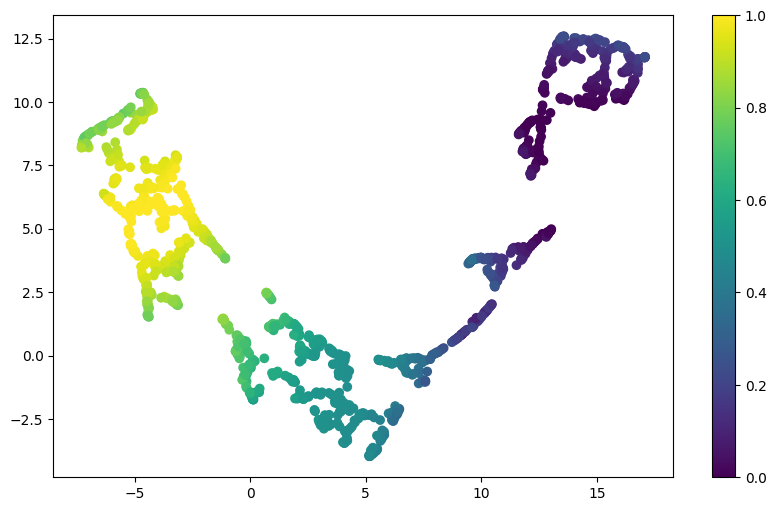

In [3]:
def fit_umap(data,n_neighbors=15, min_dist=0.01, n_components=2, metric='euclidean', title=''):
    fit = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        #random_state=1,  # Controls model initialization
        transform_seed=43,  # Controls transform() randomness
        n_epochs=1000,  # Longer training for stability
        n_jobs=1,  # Disable parallel processing for reproducibility
        #verbose=True  # Monitor convergence
    )
    u = fit.fit_transform(data)
    return u, fit
    
def plot_umap(u, data, title=""):
    n_components = u.shape[1]
    fig = plt.figure(figsize=(10, 6))
    
    # Normalize color data to [0,1] range
    norm_data = (data - np.min(data)) / (np.max(data) - np.min(data))
    
    if n_components == 2:
        ax = fig.add_subplot(111)
        sc = ax.scatter(u[:,0], u[:,1], c=norm_data[:,2], cmap='viridis', vmin=0, vmax=1)
        plt.colorbar(sc)
        
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=norm_data[:,2], cmap='viridis')
        plt.colorbar(sc)
    
    plt.title(title)


u, fit = fit_umap(Y,n_neighbors=15, min_dist=0.05, n_components=2, metric='euclidean', title='')

plot_umap(u, Y)

# Isomap

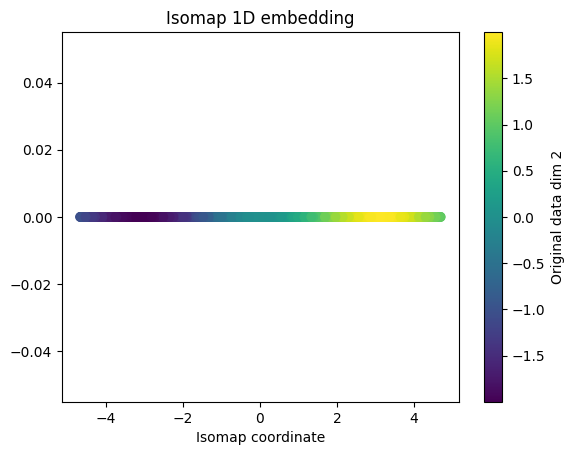

In [7]:
from sklearn import manifold

def fit_isomap(data, n_components=2, n_neighbors=15):
    isomap = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components)
    iso_embedding = isomap.fit_transform(data)
    return iso_embedding, isomap

# Suppose X is your observed (e.g. S-curve) data, shape (n_samples, n_features)
iso_embedding, isomap_model = fit_isomap(Y, n_components=1, n_neighbors=50)

# Plot Isomap embedding (optional)
import matplotlib.pyplot as plt
plt.scatter(iso_embedding[:,0], np.zeros_like(iso_embedding[:,0]), c=Y[:,2], cmap='viridis')
#plt.scatter(iso_embedding[:,0], iso_embedding[:,1], c=Y[:,2], cmap='viridis')#

plt.title("Isomap 1D embedding")
plt.xlabel("Isomap coordinate")
#plt.yticks([])
plt.colorbar(label="Original data dim 2")
plt.show()

# GPLVM

Mean Squared Error between original and reconstructed: 0.0025


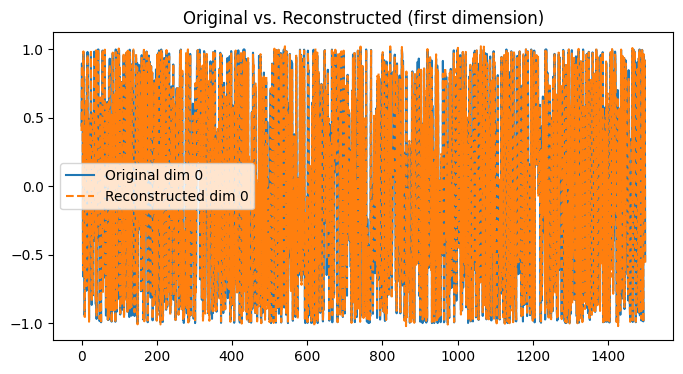

In [8]:
# Generate synthetic high-dimensional data


latent_dim = iso_embedding.shape[1] # u.shape[1] # 

# Create GPLVM with UMAP initialization
gplvm = GPy.models.GPLVM(Y, input_dim=latent_dim,  X=iso_embedding  , kernel=GPy.kern.RBF(latent_dim)) #  X=u 

gplvm.optimize(messages=True, max_iters=200)

# Extract latent variables
X_latent = gplvm.X.values

# Reconstruct the data from the latent variables
# This gives the mean prediction for each latent point
Y_reconstructed, Y_reconstructed_var = gplvm.predict(X_latent)

# Compare the original and reconstructed data
mse = mean_squared_error(Y, Y_reconstructed)
print(f"Mean Squared Error between original and reconstructed: {mse:.4f}")

# Optionally, plot first dimension of original vs reconstructed for a visual check
plt.figure(figsize=(8,4))
plt.plot(Y[:, 0], label='Original dim 0')
plt.plot(Y_reconstructed[:, 0], label='Reconstructed dim 0', linestyle='dashed')
plt.legend()
plt.title('Original vs. Reconstructed (first dimension)')
plt.show()

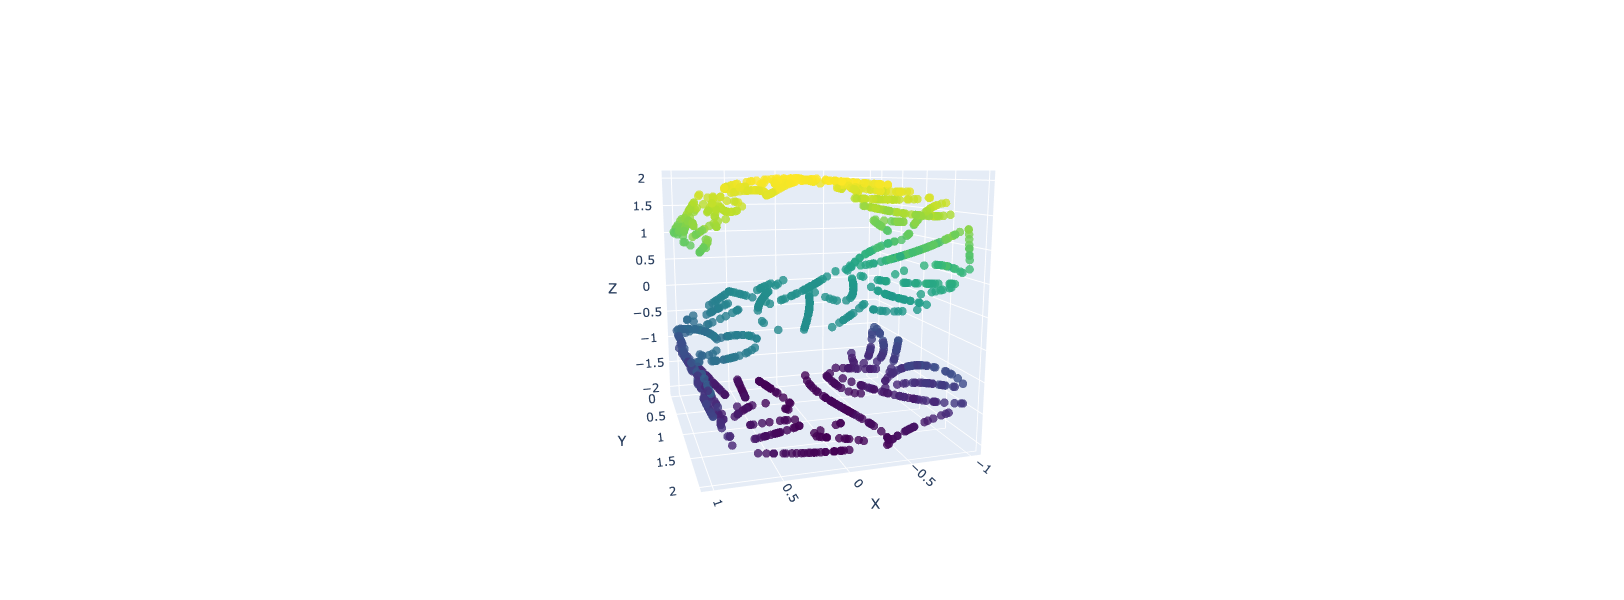

In [9]:
fig = go.Figure(data=[go.Scatter3d(
    x=Y_reconstructed[:,0],y=Y_reconstructed[:,1],z=Y_reconstructed[:,2], mode='markers', marker=dict( size=5, color=Y[:, 2], colorscale='Viridis',opacity=0.8 ) )])

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=600, height=600, margin=dict(r=30, b=20, l=20, t=20) )
fig.show()

In [30]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path

k = 100  # Adjust as needed
W = kneighbors_graph(Y, n_neighbors=k, mode='distance', include_self=False)
#W = kneighbors_graph(X_latent, n_neighbors=k, mode='distance', include_self=False)

geo_dist_matrix, predecessors = shortest_path(W, directed=False, return_predecessors=True)

geo_dist_matrix

array([[0.        , 1.73553675, 0.67729483, ..., 4.06818448, 4.76526781,
        3.03129933],
       [1.73553675, 0.        , 1.62588919, ..., 5.70395625, 6.21692284,
        4.52836416],
       [0.67729483, 1.62588919, 0.        , ..., 4.56168231, 5.34450806,
        3.61862323],
       ...,
       [4.06818448, 5.70395625, 4.56168231, ..., 0.        , 1.17900479,
        1.31756885],
       [4.76526781, 6.21692284, 5.34450806, ..., 1.17900479, 0.        ,
        1.73489811],
       [3.03129933, 4.52836416, 3.61862323, ..., 1.31756885, 1.73489811,
        0.        ]])

In [31]:
def retrieve_geodesic_path(source, target, predecessors):
    """Return the list of indices along the shortest path from source to target."""
    path = []
    k = target
    if predecessors[source, k] == -9999:  # no path
        return None
    while k != source:
        path.append(k)
        k = predecessors[source, k]
    path.append(source)
    return path[::-1]

# Example: get geodesic path between two random points
i, j = 20, 30
path_indices = retrieve_geodesic_path(i, j, predecessors)
print("Indices along path:", path_indices)
print("Geodesic distance:", geo_dist_matrix[i, j])

Indices along path: [20, 1191, 7, 783, 818, 206, 666, 485, 976, 287, 944, 1389, 30]
Geodesic distance: 6.719127326447942


In [32]:
fig = go.Figure()

# All data points in light gray
fig.add_trace(go.Scatter3d(
    x=Y[:, 0], y=Y[:, 1], z=Y[:, 2],
    mode='markers',
    marker=dict(color='lightgray', opacity=0.6, size=5),
    name='All data'
))

# Start point
fig.add_trace(go.Scatter3d(
    x=[Y[i, 0]], y=[Y[i, 1]], z=[Y[i, 2]],
    mode='markers',
    marker=dict(color='red', size=8),
    name='start'
))

# End point
fig.add_trace(go.Scatter3d(
    x=[Y[j, 0]], y=[Y[j, 1]], z=[Y[j, 2]],
    mode='markers',
    marker=dict(color='magenta', size=8),
    name='end'
))


# Geodesic path (if available)
if path_indices is not None:
    path_pts = Y[path_indices]
    fig.add_trace(go.Scatter3d(
        x=path_pts[:, 0], y=path_pts[:, 1], z=path_pts[:, 2],
        mode='lines',
        line=dict(color='black', width=6),
        name='geodesic'
    ))

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=900, height=900, margin=dict(r=30, b=20, l=20, t=20) )


fig.show()

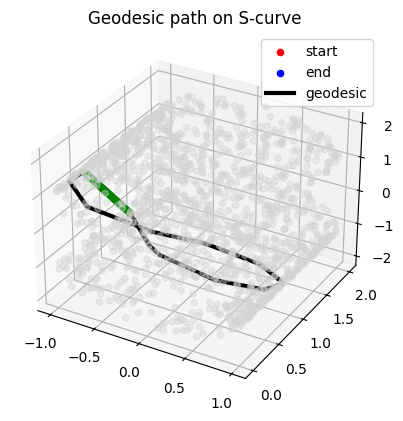

In [33]:
A = Y[i,:]
B = Y[j,:]

my_path_1 = np.linspace(A[0],B[0],100)
my_path_2 = np.linspace(A[1],B[1],100)
my_path_3 = np.linspace(A[2],B[2],100)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y[:,0], Y[:,1], Y[:,2], c='lightgray', alpha=0.4)
ax.scatter(Y[i,0], Y[i,1], Y[i,2], color='red', label='start')
ax.scatter(Y[j,0], Y[j,1], Y[j,2], color='blue', label='end')
ax.scatter(my_path_1,my_path_2,my_path_3,color= 'green')
if path_indices is not None:
    path_pts = Y[path_indices]
    ax.plot(path_pts[:,0], path_pts[:,1], path_pts[:,2], 'k-', lw=3, label='geodesic')
ax.set_title("Geodesic path on S-curve")
ax.legend()
plt.show()



In [34]:
# Taking the glvm transformation of the path and then reconstructing it

my_path = np.column_stack([my_path_1, my_path_2, my_path_3])  # shape (100, 3)

X_latents_direct_path = gplvm.infer_newX(my_path, optimize=True)


Y_reconstructed_mypath, Y_reconstructed_var = gplvm.predict(X_latents_direct_path[0])

mse = mean_squared_error(my_path, Y_reconstructed_mypath)
print(f"Mean Squared Error between original and reconstructed: {mse:.4f}")


fig = go.Figure()

# All data points in light gray
fig.add_trace(go.Scatter3d(
    x=Y[:, 0], y=Y[:, 1], z=Y[:, 2],
    mode='markers',
    marker=dict(color='lightgray', opacity=0.6, size=5),
    name='All data'
))

# Start point
fig.add_trace(go.Scatter3d(
    x=[Y[i, 0]], y=[Y[i, 1]], z=[Y[i, 2]],
    mode='markers',
    marker=dict(color='red', size=8),
    name='start'
))

# End point
fig.add_trace(go.Scatter3d(
    x=[Y[j, 0]], y=[Y[j, 1]], z=[Y[j, 2]],
    mode='markers',
    marker=dict(color='magenta', size=8),
    name='end'
))

# Path points in green (original path, as points)
fig.add_trace(go.Scatter3d(
    x=my_path_1.flatten(), y=my_path_2.flatten(), z=my_path_3.flatten(),
    mode='markers',
    marker=dict(color='green', size=4, symbol='circle'),
    name='path (input)'
))

# Reconstructed path in green (as points)
fig.add_trace(go.Scatter3d(
    x=Y_reconstructed_mypath[:, 0], y=Y_reconstructed_mypath[:, 1], z=Y_reconstructed_mypath[:, 2],
    mode='markers',
    marker=dict(color='blue', size=6, symbol='diamond'),
    name='reconstructed path'
))

# Geodesic path (if available)
if path_indices is not None:
    path_pts = Y[path_indices]
    fig.add_trace(go.Scatter3d(
        x=path_pts[:, 0], y=path_pts[:, 1], z=path_pts[:, 2],
        mode='lines',
        line=dict(color='black', width=6),
        name='geodesic'
    ))

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=900, height=900, margin=dict(r=30, b=20, l=20, t=20) )


fig.show()

Mean Squared Error between original and reconstructed: 0.0418


# Geodesics using GPLVM Jaccobian

In [11]:

def gplvm_jacobian(gplvm, x):
    """
    Compute the Jacobian of the GPLVM mapping at latent point x.
    x: shape (latent_dim,)
    Returns: shape (data_dim, latent_dim)
    """
    x = x[None, :]  # shape (1, latent_dim)
    data_dim = gplvm.Y.shape[1]
    latent_dim = x.shape[1]
    jac = np.zeros((data_dim, latent_dim))
    eps = 1e-3
    y0 = gplvm.predict(x)[0].flatten()
    for i in range(latent_dim):
        x_eps = x.copy()
        x_eps[0, i] += eps
        y_eps = gplvm.predict(x_eps)[0].flatten()
        jac[:, i] = (y_eps - y0) / eps
    return jac


def gplvm_metric(gplvm, x, reg=1e-3):
    J = gplvm_jacobian(gplvm, x)
    G = np.dot(J.T, J)
    G += np.eye(J.shape[1]) * reg
    return G  # shape (latent_dim, latent_dim)


def geodesic_path(gplvm, x0, x1,X_latents_my_graph_geo, n_points=20):
    """
    Find geodesic between x0 and x1 in latent space.
    Returns: path of shape (n_points, latent_dim)
    """
    latent_dim = x0.shape[0]
    # Initialize path as linear interpolation
    # t = np.linspace(0, 1, n_points)
    path_init = X_latents_my_graph_geo # np.outer(1 - t, x0) + np.outer(t, x1)  # (n_points, latent_dim)
    path_flat = path_init[1:-1].flatten()  # exclude endpoints for optimization

    def path_energy(path_flat):
        path = np.vstack([x0, path_flat.reshape(-1, latent_dim), x1])
        energy = 0.0
        for i in range(len(path) - 1):
            xm = 0.5 * (path[i] + path[i+1])
            G = gplvm_metric(gplvm, xm)
            dx = path[i+1] - path[i]
            energy += np.sqrt(dx @ G @ dx)
        
        # ---- Penalty for leaving the data region ----
        # For each point on the path, compute the distance to the nearest training point
        penalty = 0.0
        for x in path:
            penalty += np.min(np.linalg.norm(X_latent - x, axis=1))
        # Or, you can use a mean instead of sum, depending on your preference
        # penalty = np.mean([np.min(np.linalg.norm(X_train - x, axis=1)) for x in path])
        
        alpha = 1000 # Tune this parameter as needed (try 0.1, 1, 10, etc.)
        energy += alpha * penalty
        # --------------------------------------------
    
        return energy
    

    res = minimize(path_energy, path_flat, method='L-BFGS-B')
    path_opt = np.vstack([x0, res.x.reshape(-1, latent_dim), x1])
    return path_opt

path_points = Y[path_indices]

X_latents_my_path = gplvm.infer_newX(my_path, optimize=True)[0]  # This is (N, latent_dim)

x0 = X_latents_my_path[0]   # shape (latent_dim,)
x1 = X_latents_my_path[-1]  # shape (latent_dim,)

X_latents_my_graph_geo = gplvm.infer_newX(path_points, optimize=True)[0]  # This is (N, latent_dim)


# Compute geodesic path
geo_path = geodesic_path(gplvm, x0, x1,X_latents_my_graph_geo, n_points=100)  # shape (50, latent_dim)

# Map to data space
Y_geo_path, _ = gplvm.predict(geo_path)  # shape (50, data_dim)

KeyboardInterrupt: 

In [161]:
path_points.shape

(16, 3)

In [152]:
fig = go.Figure()

# All data points in light gray
fig.add_trace(go.Scatter3d(
    x=Y[:, 0], y=Y[:, 1], z=Y[:, 2],
    mode='markers',
    marker=dict(color='lightgray', opacity=0.4, size=3),
    name='All data'
))

# Start point
fig.add_trace(go.Scatter3d(
    x=[Y[i, 0]], y=[Y[i, 1]], z=[Y[i, 2]],
    mode='markers',
    marker=dict(color='red', size=8),
    name='start'
))

# End point
fig.add_trace(go.Scatter3d(
    x=[Y[j, 0]], y=[Y[j, 1]], z=[Y[j, 2]],
    mode='markers',
    marker=dict(color='magenta', size=8),
    name='end'
))

# Path points in green (original path, as points)
fig.add_trace(go.Scatter3d(
    x=my_path_1.flatten(), y=my_path_2.flatten(), z=my_path_3.flatten(),
    mode='markers',
    marker=dict(color='green', size=4, symbol='circle'),
    name='path (input)'
))

# # Reconstructed path in green (as points)
# fig.add_trace(go.Scatter3d(
#     x=Y_reconstructed_mypath[:, 0], y=Y_reconstructed_mypath[:, 1], z=Y_reconstructed_mypath[:, 2],
#     mode='markers',
#     marker=dict(color='blue', size=6, symbol='diamond'),
#     name='reconstructed path'
# ))

# Reconstructed path in green (as points)
fig.add_trace(go.Scatter3d(
    x=Y_geo_path[:, 0], y=Y_geo_path[:, 1], z=Y_geo_path[:, 2],
    mode='lines',
    marker=dict(color='blue', size=6, symbol='diamond'),
    name='GPLVM geodesic path'
))

# Geodesic path (if available)
if path_indices is not None:
    path_pts = Y[path_indices]
    fig.add_trace(go.Scatter3d(
        x=path_pts[:, 0], y=path_pts[:, 1], z=path_pts[:, 2],
        mode='lines',
        line=dict(color='black', width=6),
        name='K nearest geodesic'
    ))

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=900, height=900, margin=dict(r=30, b=20, l=20, t=20) )


fig.show()

In [157]:
# Linear interpolation path in latent space
t = np.linspace(0, 1, 100)
path_linear = np.outer(1 - t, x0) + np.outer(t, x1)
Y_linear, _ = gplvm.predict(path_linear)

# Geodesic path in latent space (already computed)
Y_geo_path, _ = gplvm.predict(geo_path)

# # Plot both in data space
# import matplotlib.pyplot as plt
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.plot(Y_linear[:,0], Y_linear[:,1], Y_linear[:,2], label='Linear latent path')
# ax.plot(Y_geo_path[:,0], Y_geo_path[:,1], Y_geo_path[:,2], label='Geodesic path')
# ax.legend()
# plt.show()

fig = go.Figure()

# All data points in light gray
fig.add_trace(go.Scatter3d(
    x=Y[:, 0], y=Y[:, 1], z=Y[:, 2],
    mode='markers',
    marker=dict(color='lightgray', opacity=0.4, size=3),
    name='All data'
))

# Start point
fig.add_trace(go.Scatter3d(
    x=[Y[i, 0]], y=[Y[i, 1]], z=[Y[i, 2]],
    mode='markers',
    marker=dict(color='red', size=8),
    name='start'
))

# End point
fig.add_trace(go.Scatter3d(
    x=[Y[j, 0]], y=[Y[j, 1]], z=[Y[j, 2]],
    mode='markers',
    marker=dict(color='magenta', size=8),
    name='end'
))

# Path points in green (original path, as points)
fig.add_trace(go.Scatter3d(
    x=Y_linear[:,0], y=Y_linear[:,1], z=Y_linear[:,2],
    mode='markers',
    marker=dict(color='green', size=4, symbol='circle'),
    name='linear latent path'
))


# Reconstructed path in green (as points)
fig.add_trace(go.Scatter3d(
    x=Y_geo_path[:,0], y=Y_geo_path[:,1], z=Y_geo_path[:,2],
    mode='markers',
    marker=dict(color='blue', size=6, symbol='diamond'),
    name='GPLVM geodesic path'
))

# Geodesic path (if available)
if path_indices is not None:
    path_pts = Y[path_indices]
    fig.add_trace(go.Scatter3d(
        x=path_pts[:, 0], y=path_pts[:, 1], z=path_pts[:, 2],
        mode='lines',
        line=dict(color='black', width=6),
        name='K nearest geodesic'
    ))

fig.update_layout(
    scene=dict(aspectmode='cube', xaxis_title='X', yaxis_title='Y', zaxis_title='Z',camera=dict(eye=dict(x=0.75, y=2.5, z=0.5)) ),
    width=900, height=900, margin=dict(r=30, b=20, l=20, t=20) )


fig.show()

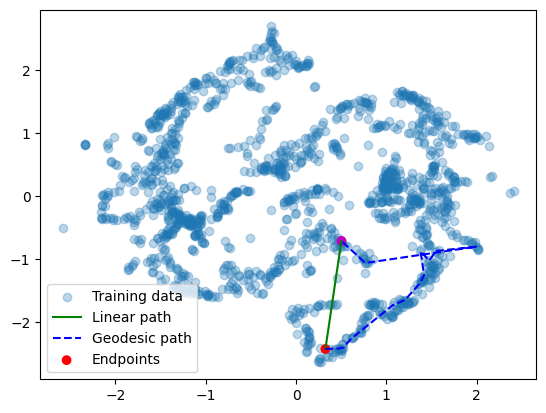

In [156]:
# Plotting the latent space

plt.scatter(X_latent[:,0], X_latent[:,1], alpha=0.3, label='Training data')
plt.plot(path_linear[:,0], path_linear[:,1], 'g-', label='Linear path')
plt.plot(geo_path[:,0], geo_path[:,1], 'b--', label='Geodesic path')
plt.scatter([x0[0], x1[0]], [x0[1], x1[1]], c=['r','m'], label='Endpoints')
plt.legend()
plt.show()

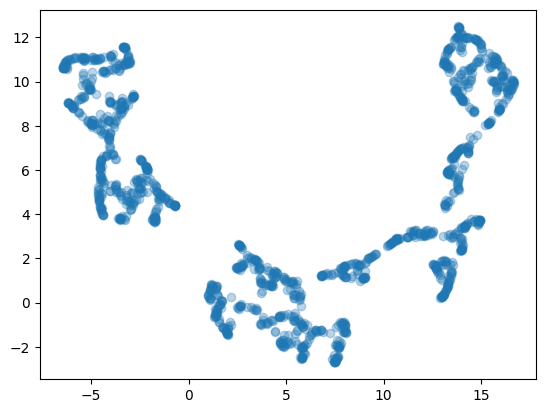

In [134]:
plt.scatter(u[:,0], u[:,1], alpha=0.3, label='Training data')


# Applying himmelblow function on the latent of the S

In [111]:
def himmelblau(x, y):
    x = x/10.
    y = y/10.
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

In [141]:

# Compute Himmelblau values on the latent space
himmelblau_vals = himmelblau(X_latent[:, 0], X_latent[:, 1])  # shape (N,)

fig = go.Figure(data=[go.Scatter3d(
    x=Y[:, 0], y=Y[:, 1], z=Y[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=himmelblau_vals,  # <-- use Himmelblau here!
        colorscale='Viridis',
        opacity=0.8,
        colorbar=dict(title='Himmelblau')
    )
)])

fig.update_layout(
    scene=dict(
        aspectmode='cube',
        xaxis_title='X', yaxis_title='Y', zaxis_title='Z',
        camera=dict(eye=dict(x=0.75, y=2.5, z=0.5))
    ),
    width=600, height=600,
    margin=dict(r=30, b=20, l=20, t=20)
)
fig.show()

<function matplotlib.pyplot.show(close=None, block=None)>

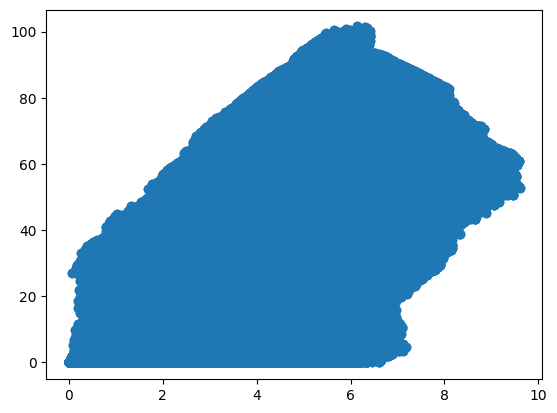

In [113]:
from sklearn.neighbors import kneighbors_graph

k = 20  # Adjust as needed
W = kneighbors_graph(Y, n_neighbors=k, mode='distance', include_self=False)

from scipy.sparse.csgraph import shortest_path

geo_dist_matrix, predecessors = shortest_path(W, directed=False, return_predecessors=True)


my_delta_y = np.abs(np.subtract.outer(himmelblau_vals,himmelblau_vals))


plt.scatter(geo_dist_matrix.flatten(),my_delta_y.flatten())
plt.show

In [61]:
geo_dist_matrix.shape

(1500, 1500)

<function matplotlib.pyplot.show(close=None, block=None)>

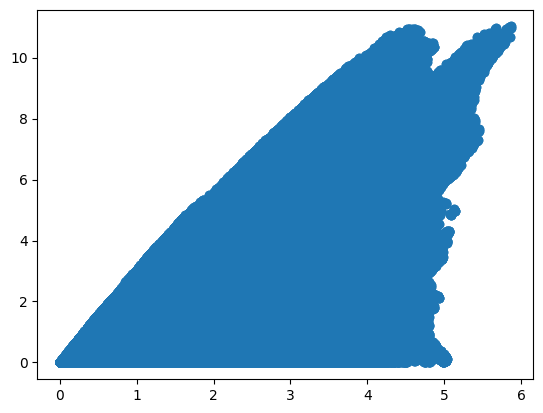

In [142]:
from sklearn.neighbors import kneighbors_graph

k = 20  # Adjust as needed
W = kneighbors_graph(X_latent, n_neighbors=k, mode='distance', include_self=False)

from scipy.sparse.csgraph import shortest_path

geo_dist_matrix, predecessors = shortest_path(W, directed=False, return_predecessors=True)


my_delta_y = np.abs(np.subtract.outer(himmelblau_vals,himmelblau_vals))


plt.scatter(geo_dist_matrix.flatten(),my_delta_y.flatten())
plt.show

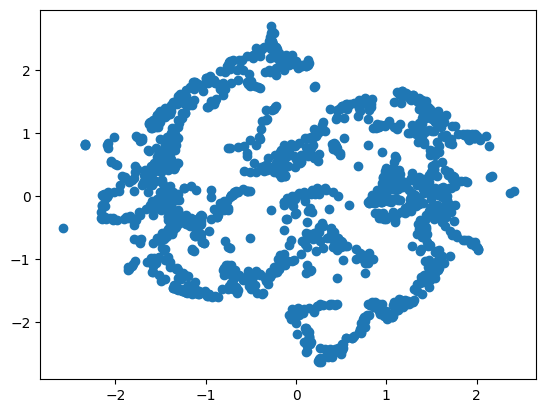

In [143]:
plt.scatter(X_latent[:,0],X_latent[:,1])